In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as pt

In [2]:
sb.set_style('white')

In [3]:
cancer = pd.read_csv('ECOMPCTNSA.xls')

In [4]:
cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28472\2124869308.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x='benign_0__mal_1', data=cancer, palette='Set1')


<Axes: xlabel='benign_0__mal_1', ylabel='count'>

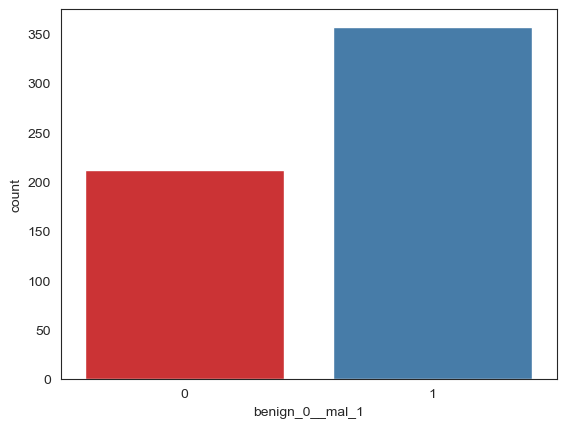

In [5]:
sb.countplot(x='benign_0__mal_1', data=cancer, palette='Set1')

<Axes: >

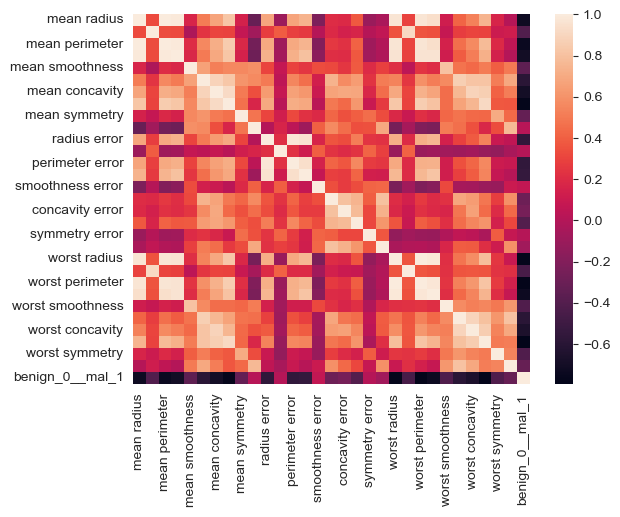

In [7]:
sb.heatmap(cancer.corr()) #This will explain how the each features are correlated to each other

**Let's Train, Test and Model**

In [8]:
X = cancer.drop('benign_0__mal_1', axis=1) #Here this is the feature dataset
y = cancer['benign_0__mal_1'] #Target variable

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [11]:
from sklearn.preprocessing import MinMaxScaler #This is the module which will scale the dataset to model predictions

In [12]:
scaler = MinMaxScaler()

In [13]:
X_train = scaler.fit_transform(X_train) #Overrride the train, test dataset
X_test = scaler.transform(X_test)

In [14]:
scaler.fit(X_train)

MinMaxScaler()

**Now let's  create the layer model and add the neurons and required activation function to it**

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

D:\Rohan\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [16]:
model=Sequential()
model.add(Dense(30, activation='relu')) #Input function with relu activation function
model.add(Dense(15, activation='relu'))

model.add(Dense(1, activation='sigmoid')) #Output layer with only 1 neuron with sigmoid function

In [17]:
model.compile(loss='binary_crossentropy', optimizer='adam')

In [18]:
model.fit(x=X_train, y=y_train, epochs=600, validation_data=(X_test, y_test))

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.6758 - val_loss: 0.6625
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6444 - val_loss: 0.6305
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6131 - val_loss: 0.5986
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5793 - val_loss: 0.5605
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5402 - val_loss: 0.5182
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4955 - val_loss: 0.4671
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4464 - val_loss: 0.4134
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3969 - val_loss: 0.3625
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3510 - val_loss: 0.3183
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3116 - val_loss: 0.2782
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2814 - val_loss: 0.2514
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - l

In [19]:
losses = pd.DataFrame(model.history.history)

<Axes: >

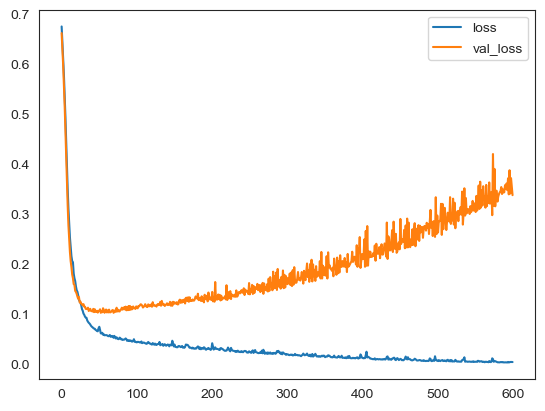

In [20]:
losses.plot()

**This above graph tells that the model is overfitted, Now let's fix this issue**

In [21]:
model=Sequential()
model.add(Dense(30, activation='relu')) 
model.add(Dense(15, activation='relu'))

model.add(Dense(1, activation='sigmoid')) 

In [22]:
model.compile(loss='binary_crossentropy', optimizer='adam')

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

In [24]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [25]:
model.fit(x=X_train, y=y_train, epochs=600, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.7027 - val_loss: 0.6757
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6630 - val_loss: 0.6476
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6318 - val_loss: 0.6167
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5962 - val_loss: 0.5774
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5513 - val_loss: 0.5244
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4976 - val_loss: 0.4668
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4396 - val_loss: 0.4068
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3847 - val_loss: 0.3509
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3362 - val_loss: 0.3051
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2987 - val_loss: 0.2679
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2651 - val_loss: 0.2380
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 

In [46]:
test_loss = pd.DataFrame(model.history.history)

<Axes: >

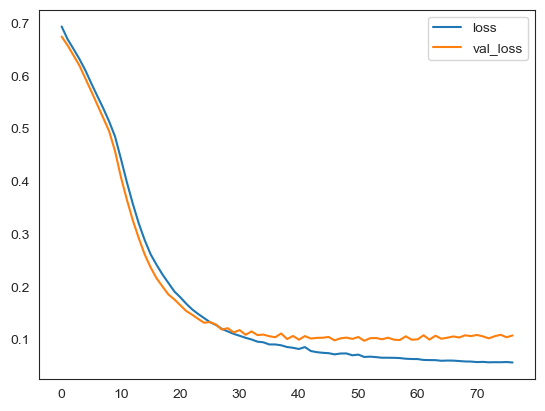

In [47]:
test_loss.plot()

**Here at 127th training it stopped the training to avoid the over fitting, still it need to be optimized let's do it using DropOut**

**Drop Out : What this method will do is that it will take some n% of the neurons from your created layers and turn them off randomly selected neurons to avoid the overfitting**

In [35]:
from tensorflow.keras.layers import Dropout

In [36]:
model=Sequential()
model.add(Dense(30, activation='relu')) #Here 50% of the neurons we took them randomly and turned them off to avoid the overfitting
model.add(Dropout(0.4))

model.add(Dense(15, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(1, activation='sigmoid')) 
model.compile(loss='binary_crossentropy', optimizer='adam')

In [37]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [38]:
model.fit(x=X_train, y=y_train, epochs=600, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.6990 - val_loss: 0.6624
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6598 - val_loss: 0.6334
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6221 - val_loss: 0.5997
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5941 - val_loss: 0.5657
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6009 - val_loss: 0.5308
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5508 - val_loss: 0.4999
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5169 - val_loss: 0.4659
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4981 - val_loss: 0.4310
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4667 - val_loss: 0.4004
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4468 - val_loss: 0.3720
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4266 - val_loss: 0.3480
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss

In [39]:
new_loss = pd.DataFrame(model.history.history)

<Axes: >

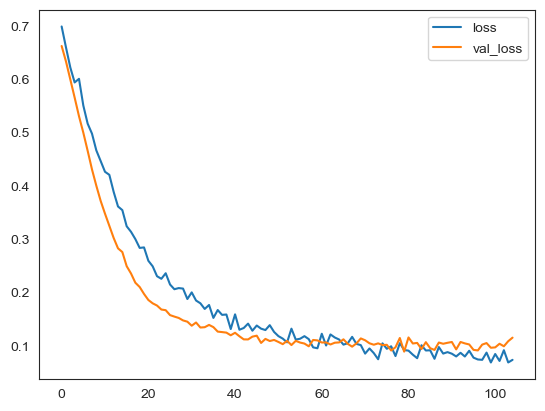

In [40]:
new_loss.plot()

In [41]:
pt.savefig('loss_graph.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [42]:
test_df = cancer.head(1).drop('benign_0__mal_1', axis=1)

In [43]:
test_transform = scaler.transform(test_df)

D:\Rohan\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


In [44]:
int(model.predict(test_transform)) #Here it has predicted 0 means it's beingn and its true from thr real dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28472\1671623169.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(model.predict(test_transform)) #Here it has predicted 0 means it's beingn and its true from thr real dataset


0

In [45]:
predictions = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [47]:
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int).flatten()

print(classification_report(y_test, predictions))
print("\n")
print("Accuracy Score : ", accuracy_score(y_test, predictions))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

           0       0.90      0.98      0.94        55
           1       0.99      0.93      0.96        88

    accuracy                           0.95       143
   macro avg       0.94      0.96      0.95       143
weighted avg       0.95      0.95      0.95       143



Accuracy Score :  0.951048951048951


**So we go almost better predictions and the 98% accuracy which is the good sign and model is fitted perfectly**